# Classical analisis

Importing modules and data

In [1]:
import descriptive as desc
from IPython.display import display,Markdown #,HTML
from statsmodels.formula.api import ols
import statsmodels.api as sm
import numpy as np
from scipy import stats
from matplotlib import pyplot as plt
import matplotlib.cm as cm
import pandas as pd
from scipy.stats import pearsonr
import scipy.stats as st
import sympy
from sklearn.datasets import load_iris
import scipy.stats as st

---
## Analysis 1
Method      : check descriptive data  
Data related: Grade, study time, absences, and failures  
Objective   : To find nice groups.

##### Note: I classified each of study time, absences, and failures into two groups. Those groups are described as dummy variable below:
- study time → deligence: calculated by whether its study time exceeds the half of the scale: 2.
- failures   → experience of failure: Once and more: 1, no failure: 0
- absences   → participance: calculated by whether its absence exceeds the mean of the population.

The "group" made from diligence + experience fo failure + participation.
e.g., n_y_n means group whose people: are not diligent, have failed, and doesn't participate much.

In [10]:
about = desc.df.groupby("group")["Grade"].agg(["mean", "std", "count"])
print(about)

            mean       std  count
group                            
n_n_n  11.175325  4.308577    154
n_n_y  10.858974  3.340909     78
n_y_n   4.628571  4.808606     35
n_y_y   9.416667  2.862317     36
y_n_n  11.377358  5.230188     53
y_n_y  12.592593  2.925475     27
y_y_n   6.571429  6.373307      7
y_y_y  11.200000  1.788854      5


### Brief discussion 1

Considering 3, 4, and 8th row have lower mean, and others high. As general tendency, it seems that 
- study time increases grade
- failure decreases grade
- participance increase grade (absence decreases grade)


However, with a close look, it also seems that
- participance decreases grade a bit when student doesn't study and have never failed

---
## Analysis 2
Method      : ANOVA  
Data related: Grade and all other IVs  
Objective   : To see which IVs determines/ relates with grade, just in case.

In [3]:

nnn   = desc.df[desc.df["group"] == "n_n_n"]
nny   = desc.df[desc.df["group"] == "n_n_y"]
nyn   = desc.df[desc.df["group"] == "n_y_n"]
nyy   = desc.df[desc.df["group"] == "n_y_y"]
ynn   = desc.df[desc.df["group"] == "y_n_n"]
yny   = desc.df[desc.df["group"] == "y_n_y"]
yyn   = desc.df[desc.df["group"] == "y_y_n"]
yyy   = desc.df[desc.df["group"] == "y_y_y"]


site1 = np.array(nnn["Grade"])
site2 = np.array(nny["Grade"])
site3 = np.array(nyn["Grade"])
site4 = np.array(nyy["Grade"])
site5 = np.array(ynn["Grade"])
site6 = np.array(yny["Grade"])
site7 = np.array(yyn["Grade"])
site8 = np.array(yyy["Grade"])

results = stats.f_oneway(site1, site2, site3, site4, site5, site6, site7, site8)

print(results)

F_onewayResult(statistic=np.float64(13.2188496760009), pvalue=np.float64(2.6663406853021654e-15))


### Brief discussion 2

It seems those groups of data have some sort of difference

---
## Analysis 3
Method      : paired t-test
</br>
Data related: Grade, study time, absences, and failures
</br>
Objective   : To do t-test with all those data, and examine if what I assumed in analysis 1 were right.

In [8]:
def Analysis_3():
    Sdf = [site1, site2, site3, site4, site5, site6, site7, site8]
    groups = ["nnn", "nny", "nyn", "nyy", "ynn", "yny", "yyn", "yyy"]
    n = len(Sdf)
    p_matrix = np.zeros((8, 8))

    for i in range (0, 8):
        for j in range (0, 8):
            if i == j:
                p_matrix[i, j] = np.nan
            elif j < i :
                _,p    = stats.ttest_ind(Sdf[i], Sdf[j])
                p_matrix[i, j] = p
            else:
                p_matrix[i, j] = np.nan
            
    df_p = pd.DataFrame(p_matrix, columns= groups, index= groups)
    signi_p = df_p.style.map(desc.color_positive_green)
    return signi_p

Analysis_3()

,nnn,nny,nyn,nyy,ynn,yny,yyn,yyy
nnn,nan,nan,nan,nan,nan,nan,nan,nan
nny,0.570887,nan,nan,nan,nan,nan,nan,nan
nyn,0.000000,0.000000,nan,nan,nan,nan,nan,nan
nyy,0.020904,0.027226,0.000003,nan,nan,nan,nan,nan
ynn,0.781133,0.489940,0.000000,0.043558,nan,nan,nan,nan
yny,0.102306,0.018402,0.000000,0.000059,0.266495,nan,nan,nan
yyn,0.007575,0.003773,0.360630,0.062498,0.029654,0.000765,nan,nan
yyy,0.989853,0.822337,0.004776,0.185353,0.940574,0.315283,0.149643,nan


### Brief discussion 3

Pairs whose p-value is less than 0.05 is highlighted by green. To make it easy to read, I'll extract only the 5 pairs one of whose two of the properties(e.g. nyn) are identical to the other. 

Significant result: **nnn to nyn, nny to nyy, nny to yny, nyn to nyy, ynn to yyn.**

Again, the "group" made from diligence + experience fo failure + participation. (e.g., n_y_n means group whose people: are not diligent, have failed, and doesn't participate much.) So, the result, combined with the average grade showed in analysis 1, implies that:
- failures decrease grade both of when: students don't study much, and student study much but doesn't participate much.
- study time increase grade when students have no experience of failure and participate well.
- experience of failure decrease grade when students study well and don't participate well.

In contrast with this, I review the four analysis in the first analysis:

1. study time increases grade
2. failure decreases grade
3. participance increase grade (absence decreases grade)
4. participance decreases grade a bit when student doesn't study and have never failed

According to the result of the analysis 3, part of 1, 2, and 3 were supported, while 4 doesn't seem significant.

### Visualization

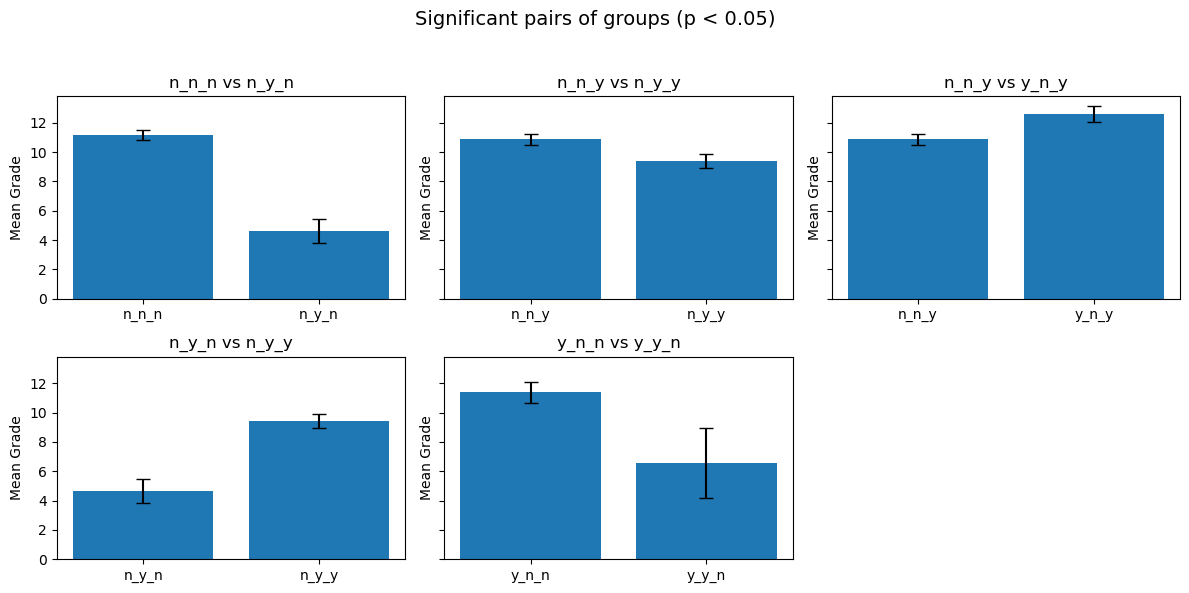

In [19]:
about["se"] = about["std"] / np.sqrt(about["count"])
order = ["n_n_n", "n_n_y", "n_y_n", "n_y_y", "y_n_n", "y_n_y", "y_y_n", "y_y_y"]

fig, axes = plt.subplots(2, 3, figsize=(12, 6), sharey=True)
axes = axes.flatten()

def First_analysis():
    pairs_short = [("nnn", "nyn"), ("nny", "nyy"), ("nny", "yny"), ("nyn", "nyy"), ("ynn", "yyn")]
    for i, (c1, c2) in enumerate(pairs_short):
        g1 = desc.expand_code(c1)
        g2 = desc.expand_code(c2)
        ax = axes[i]
        m1 = about.loc[g1, "mean"]
        n1 = about.loc[g1, "count"]
        sd1 = about.loc[g1, "std"]
        se1 = sd1 / np.sqrt(n1)
        m2 = about.loc[g2, "mean"]
        n2 = about.loc[g2, "count"]
        sd2 = about.loc[g2, "std"]
        se2 = sd2 / np.sqrt(n2)
        means = [m1, m2]
        ses = [se1, se2]
        x = [0, 1]
        ax.bar(x, means, yerr=ses, capsize=5)
        ax.set_xticks(x)
        ax.set_xticklabels([g1, g2], rotation=0)
        ax.set_ylabel("Mean Grade")
        ax.set_title(f"{g1} vs {g2}")
    if len(axes) > len(pairs_short):
        for j in range(len(pairs_short), len(axes)):
            axes[j].axis("off")

    fig.suptitle("Significant pairs of groups (p < 0.05)", fontsize=14)
    fig.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

First_analysis()

---
## Analysis 4
Method      : Same as analysis 1 and 3
</br>
Data related: grade, mother's education, father's education, and go out
</br>
Objective   : To find nice groups.

In [7]:
about = desc.df.groupby("group_2")["Grade"].agg(["mean", "std", "count"])
print(about)

              mean       std  count
group_2                            
n_n_n     9.790698  4.522145     86
n_n_y     8.040816  4.725636     49
n_y_n    11.000000  3.611576     24
n_y_y     8.833333  4.996666      6
y_n_n    12.022222  4.408096     45
y_n_y     9.473684  4.060219     19
y_y_n    11.465347  4.423945    101
y_y_y    10.492308  4.589809     65


### Brief discussion 4

Considering 1, 2, 4, and 6th row have lower mean, and others high. As general tendency, it seems that 
- mother's education time increases grade
- failure decreases grade
- participance increase grade (absence decreases grade)


However, with a close look, it also seems that
- participance decreases grade a bit when student doesn't study and have never failed

---
## Analysis 
Method      : 
</br>
Data related:
</br>
Objective   : 